## --- Generate text with a recurrent neural network (Pytorch) ---
### (Mostly Read & Run)

The goal is to replicate the (famous) experiment from [Karpathy's blog](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)

To learn to generate text, we train a recurrent neural network to do the following task:

Given a "chunk" of text: `this is random text`

the goal of the network is to predict each character in **`his is random text` ** sequentially given the following sequential input **`this is random tex`**:




## Load text (dataset/input.txt)

Before building training batch, we load the full text in RAM

In [1]:
!wget https://thome.isir.upmc.fr/classes/RITAL/input.txt

--2026-03-27 17:33:49--  https://thome.isir.upmc.fr/classes/RITAL/input.txt
Résolution de thome.isir.upmc.fr (thome.isir.upmc.fr)… 134.157.18.247
Connexion à thome.isir.upmc.fr (thome.isir.upmc.fr)|134.157.18.247|:443… connecté.
requête HTTP transmise, en attente de la réponse… 200 OK
Taille : 1115394 (1,1M) [text/plain]
Sauvegarde en : « input.txt.2 »

input.txt.2         100%[===================>]   1,06M  --.-KB/s    ds 0,1s    

2026-03-27 17:33:49 (8,02 MB/s) — « input.txt.2 » sauvegardé [1115394/1115394]



In [2]:
#!pip install unidecode

In [10]:
import unidecode
import string
import random
import re
import torch
import torch.nn as nn

all_characters = string.printable
n_characters = len(all_characters)
print(n_characters)

file = unidecode.unidecode(open('./input.txt').read()) #clean text => only ascii
file_len = len(file)
print('file_len =', file_len)

100
file_len = 1115394


## 2: Helper functions:

We have a text and we want to feed batch of chunks to a neural network:

one chunk  A,B,C,D,E
[input] A,B,C,D -> B,C,D,E [output]

Note: we will use an embedding layer instead of a one-hot encoding scheme.

for this, we have 3 functions:

- One to get a random str chunk of size `chunk_len` : `random_chunk`
- One to turn a chunk into a tensor of size `(1,chunk_len)` coding for each characters : `char_tensor`
- One to return random input and output chunks of size `(batch_size,chunk_len)` : `random_training_set`




In [4]:
import time, math


#Get a piece of text
def random_chunk(chunk_len):
    start_index = random.randint(0, file_len - chunk_len)
    end_index = start_index + chunk_len + 1
    return file[start_index:end_index]


# Turn string into list of longs
def char_tensor(string):
    tensor = torch.zeros(1,len(string)).long()
    for c in range(len(string)):
        tensor[0,c] = all_characters.index(string[c])
    return tensor


#Turn a piece of text in train/test
def random_training_set(chunk_len=200, batch_size=8):
    chunks = [random_chunk(chunk_len) for _ in range(batch_size)]
    inp = torch.cat([char_tensor(chunk[:-1]) for chunk in chunks],dim=0)
    target = torch.cat([char_tensor(chunk[1:]) for chunk in chunks],dim=0)

    return inp, target

print(random_training_set(10,4))  ## should return 8 chunks of 10 letters.

(tensor([[94, 60, 14, 29, 94, 16, 18, 31, 14, 94],
        [34, 94, 21, 18, 29, 29, 21, 14, 94, 21],
        [10, 29, 94, 17, 14, 94, 32, 24, 30, 21],
        [21, 94, 23, 24, 29, 94, 22, 10, 27, 27]]), tensor([[60, 14, 29, 94, 16, 18, 31, 14, 94, 30],
        [94, 21, 18, 29, 29, 21, 14, 94, 21, 14],
        [29, 94, 17, 14, 94, 32, 24, 30, 21, 13],
        [94, 23, 24, 29, 94, 22, 10, 27, 27, 34]]))


## The actual RNN model (only thing to complete):

It should be composed of three distinct modules:

- an [embedding layer](https://pytorch.org/docs/stable/nn.html#embedding) (n_characters, hidden_size)

```
nn.Embedding(len_dic,size_vec)
```
- a [recurrent](https://pytorch.org/docs/stable/nn.html#recurrent-layers) layer (hidden_size, hidden_size)
```
nn.RNN(in_size,out_size) or nn.GRU() or nn.LSTM() => rnn_cell parameter
```
- a [prediction](https://pytorch.org/docs/stable/nn.html#linear) layer (hidden_size, output_size)

```
nn.Linear(in_size,out_size)
```
=> Complete the `init` function code

In [5]:
import torch.nn.functional as f

class RNN(nn.Module):

    def __init__(self, n_char, hidden_size, output_size, n_layers=1, rnn_cell=nn.RNN):
        """
        Create the network
        """
        super(RNN, self).__init__()

        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers

        #  (batch,chunk_len) -> (batch, chunk_len, hidden_size)
        self.embed = nn.Embedding(n_char, hidden_size)

        # (batch, chunk_len, hidden_size)  -> (batch, chunk_len, hidden_size)
        self.rnn = rnn_cell(hidden_size, hidden_size, batch_first=True, num_layers=n_layers)

        #(batch, chunk_len, hidden_size) -> (batch, chunk_len, output_size)
        self.predict = nn.Linear(hidden_size, output_size)

    def forward(self, input):
        """
        batched forward: input is (batch > 1,chunk_len)
        """
        input = self.embed(input)
        output,_  = self.rnn(input)
        output = self.predict(f.tanh(output))
        return output

    def forward_seq(self, input,hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.rnn(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden


## Text generation function

Sample text from the model

In [6]:
def generate(model,prime_str='A', predict_len=100, temperature=0.8):
    prime_input = char_tensor(prime_str).squeeze(0)
    hidden = None
    predicted = prime_str+""
    # Use priming string to "build up" hidden state

    for p in range(len(prime_str)-1):
        _,hidden = model.forward_seq(prime_input[p].unsqueeze(0),hidden)

    #print(hidden.size())
    for p in range(predict_len):
        output, hidden = model.forward_seq(prime_input[-1].unsqueeze(0), hidden)
                # Sample from the network as a multinomial distribution
        #output_dist = output.data.view(-1).div(temperature).exp()
        #print(output_dist)
        #top_i = torch.multinomial(output_dist, 1)[0]
        output_dist = torch.softmax(output.view(-1).div(temperature), dim=0)
        top_i = torch.multinomial(output_dist, 1)[0]
        #print(top_i)
        # Add predicted character to string and use as next input
        predicted_char = all_characters[top_i]
        predicted += predicted_char
        prime_input = torch.cat([prime_input,char_tensor(predicted_char).squeeze(0)])

    return predicted



## Training loop for net

In [7]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

####

model = RNN(n_characters, hidden_size, n_characters, n_layers) #create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    #compute loss
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))

    #compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()



for epoch in range(1, n_epochs + 1):
    loss = train(*random_training_set(chunk_len,batch_size))  #train on one chunk
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0


 1s (100 0%) 2.7120]
Whe nopist lot to t taco't ar yoicol the yaP id the yhace hater geabife  to fate an tunen ureoUt rodn: 

 2s (200 1%) 2.3259]
Whre'ld
In reave sor be
hav araln the torde are fos Anded of condensos
art, for thage, bors dor miple  

 4s (300 1%) 2.2659]
Whes alk thith?
Bone!

E:
To the sodans nos mre bintte marcordiles the, ant'
Hing of hadiqe.

MELENA:
 

 5s (400 2%) 2.1102]
Whore irile, and milt ilors rents the not
All chor: if cheived apigh he and sneet be Wheld thy the sut 

 7s (500 2%) 2.0511]
Whit whus sword them chate fo steven father lentare of in lord,
Thy for well your were hind the dilt d 

 8s (600 3%) 2.0175]
Wherfel so sake this the in to sile the neate the can onow.
Shadn tisfeet; wheveds uness, fate us unga 

 10s (700 3%) 2.0184]
Whitul wunder and thear the hing mice has the wrentien kuth with to shive perent sulger his like of le 

 11s (800 4%) 2.0682]
Whew wing of we dreinius fore of sitpelm on when, for gear wrom not and comaer me and gother wh

## Visualize loss

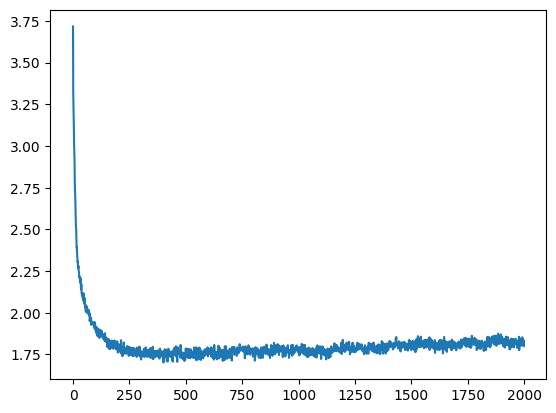

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
%matplotlib inline

plt.figure()
plt.plot(all_losses)

## Try different temperatures

Changing the distribution sharpness has an impact on character sampling:

more or less probable things are sampled

In [9]:
print(generate(model,'T', 200, temperature=1))
print("----")
print(generate(model,'Th', 200, temperature=0.8))
print("----")

print(generate(model,'Th', 200, temperature=0.5))
print("----")

print(generate(model,'Th', 200, temperature=0.3))
print("----")

print(generate(model,'Th', 200, temperature=0.1))

This brercisair'd.

HORTHUCELLA:
Mispide,
To I their bongal owirig hich.

LAURTISGY HENRTIANIL:
Noir
pure jrooy instre commy me hondanet of prither.

ANIOLIO:
What a mae,
Rhor or master didion with be 
----
Thenvingss our dipages with therefore shall and a there caust,
To sincate the may curtul hack this grote this perve the keaks for than, lroth all feard musting dampses a piranity good here so noble will
----
There detool of this do I marry thou with pirst how the to here thee a servaming poing it, your shall a man be long the couse this be citize the live the shall should the say,
Than this prock of you hav
----
There be pray the dead, and in the deveress to his shall the stand the couder to the sease and the protion me procut the be the prock the be all be the seemly that the like some and poon the prock and b
----
There the pross the seemly the seemly the shall the so so streath the see the seemly the shall the so so process the pross the seemly the seemly the seemly the seemly th

### Improving this code:

(a) Tinker with parameters:

- Is it really necessary to have 100 dims character embeddings
- Chunk length can be gradually increased
- Try changing RNN cell type (GRUs - LSTMs)

(b) Add GPU support to go faster


100 dims per character is very high, I don't think characters contain as much information as words for example, and 100 dims is usually the size of word embeddings.

In [26]:
class GRU(nn.Module):
    def __init__(self, n_char, hidden_size, output_size, n_layers=1):
        super().__init__()
        
        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.embed = nn.Embedding(n_char, hidden_size)
        
        self.gru = nn.GRU(hidden_size, hidden_size, num_layers=n_layers, batch_first=True)
        self.predict = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        #h0= torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        x = self.embed(x)
        out, _ = self.gru(x)
        output = self.predict(f.tanh(out))
        return output

    def forward_seq(self, input, hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.gru(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden

In [29]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 25 #100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GRU(n_characters, hidden_size, n_characters, n_layers) #create model
model.to(device)
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    #compute loss
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))

    #compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()



for epoch in range(1, n_epochs + 1):
    inp, target = random_training_set(chunk_len, batch_size)
    inp = inp.to(device)
    target = target.to(device)
    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0

 2s (100 0%) 3.4095]
 4s (200 1%) 3.2859]
 6s (300 1%) 3.2685]
 8s (400 2%) 3.0499]
 10s (500 2%) 2.8134]
 13s (600 3%) 2.6111]
 15s (700 3%) 2.5739]
 17s (800 4%) 2.3534]
 19s (900 4%) 2.3980]
 21s (1000 5%) 2.1553]
 23s (1100 5%) 2.2965]
 25s (1200 6%) 2.1661]
 27s (1300 6%) 2.1824]
 30s (1400 7%) 2.1493]
 32s (1500 7%) 2.1574]
 34s (1600 8%) 2.0687]
 36s (1700 8%) 2.1814]
 38s (1800 9%) 2.0255]
 41s (1900 9%) 1.9876]
 43s (2000 10%) 1.9950]
 45s (2100 10%) 2.0216]
 47s (2200 11%) 2.0085]
 49s (2300 11%) 1.9070]
 51s (2400 12%) 1.9028]
 54s (2500 12%) 2.0330]
 56s (2600 13%) 2.0154]
 58s (2700 13%) 1.9465]
 0s (2800 14%) 1.9765]
 2s (2900 14%) 1.9950]
 4s (3000 15%) 1.8701]
 6s (3100 15%) 1.8804]
 9s (3200 16%) 1.9281]
 11s (3300 16%) 1.9337]
 13s (3400 17%) 1.9348]
 15s (3500 17%) 1.9204]
 17s (3600 18%) 1.8954]
 19s (3700 18%) 1.8519]
 21s (3800 19%) 1.8624]
 24s (3900 19%) 1.8677]
 26s (4000 20%) 1.8148]
 28s (4100 20%) 1.8524]
 30s (4200 21%) 1.8833]
 32s (4300 21%) 1.9424]
 35s 

In [ ]:
class LSTM(nn.Module):
    def __init__(self, n_char, hidden_size, output_size, n_layers=1):
        super().__init__()
        
        self.n_char = n_char
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.embed = nn.Embedding(n_char, hidden_size)
        
        self.lstm = nn.LSTM(hidden_size, hidden_size, n_layers=n_layers, batch_first= True)
        self.predict = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        #h0= torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)

        x = self.embed(x)
        out, _ = self.lstm(x)
        output = self.predict(f.tanh(out))
        return output

    def forward_seq(self, input, hidden=None):
        """
        not batched forward: input is  (1,chunk_len)
        """
        input = self.embed(input)
        output,hidden  = self.lstm(input.unsqueeze(0),hidden)
        output = self.predict(f.tanh(output))
        return output,hidden

In [ ]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

###Parameters
n_epochs = 20000
print_every = 100
plot_every = 10
hidden_size = 100
n_layers = 5
lr = 0.005
batch_size = 16
chunk_len = 80

model = LSTM(n_characters, hidden_size, n_characters, n_layers) #create model
model_optimizer = torch.optim.Adam(model.parameters(), lr=lr) #create Adam optimizer
criterion = nn.CrossEntropyLoss() #chose criterion

start = time.time()
all_losses = []
loss_avg = 0


def train(inp, target):
    """
    Train sequence for one chunk:
    """
    #reset gradients
    model_optimizer.zero_grad()

    # predict output
    output = model(inp)

    #compute loss
    loss =  criterion(output.view(batch_size*chunk_len,-1), target.view(-1))

    #compute gradients and backpropagate
    loss.backward()
    model_optimizer.step()

    return loss.data.item()

for epoch in range(1, n_epochs + 1):
    inp, target = random_training_set(chunk_len, batch_size)
    inp = inp.to(device)
    target = target.to(device)
    loss = train(inp, target)
    loss_avg += loss

    if epoch % print_every == 0:
        print('[%s (%d %d%%) %.4f]' % (time_since(start), epoch, epoch / n_epochs * 100, loss))
        print(generate(model,'Wh', 100), '\n')



    if epoch % plot_every == 0:
        all_losses.append(loss_avg / plot_every)
        loss_avg = 0